# Statistical Baselines: SARIMA and Exponential Smoothing

In [1]:
import importlib.util
import os
import random
import subprocess
import sys
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)
random.seed(42)

In [2]:
candidate_paths = [
    "/kaggle/input/total-consumption-data/total_consumption_data.csv",
    "/kaggle/input/datasets/rahulsarav/total-consumption-data/total_consumption_data.csv",
    "/kaggle/input/total_consumption_data.csv",
    "total_consumption_data.csv"
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("total_consumption_data.csv was not found in expected Kaggle/local paths")

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

if np.issubdtype(df["datetime"].dtype, np.number):
    df["datetime"] = pd.to_datetime(df["datetime"], unit="s", errors="coerce")
else:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

for col in df.columns:
    if col not in ["datetime", "meter_id"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

target_col = "apower_ph1" if "apower_ph1" in df.columns else "apower"
df = df.dropna(subset=["datetime", target_col]).copy()
df["hour"] = df["datetime"].dt.floor("h")

series = df.groupby("hour")[target_col].sum().sort_index().astype(float)

n = len(series)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = series.iloc[:train_end]
val = series.iloc[train_end:val_end]
test = series.iloc[val_end:]

print("Data path:", data_path)
print("Target column:", target_col)
print("Series length:", len(series))
print("Train/Val/Test lengths:", len(train), len(val), len(test))

Data path: /kaggle/input/datasets/rahulsarav/total-consumption-data/total_consumption_data.csv
Target column: apower_ph1
Series length: 417
Train/Val/Test lengths: 291 63 63


In [3]:
def pick_d(series_in, max_d=2, alpha=0.05):
    pvals = {}
    for d in range(max_d + 1):
        s = series_in.diff(d).dropna() if d > 0 else series_in.dropna()
        if len(s) < 30:
            continue
        p = adfuller(s, autolag="AIC")[1]
        pvals[d] = float(p)
        if p < alpha:
            return d, pvals
    if len(pvals) == 0:
        return 0, pvals
    return min(pvals, key=pvals.get), pvals

def metric_row(name, y_true, y_pred):
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "R2": float(r2_score(yt, yp)),
        "MAPE(%)": float(np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-6))) * 100.0)
    }

d_order, pvals = pick_d(train, max_d=2, alpha=0.05)
print("Chosen non-seasonal differencing order:", d_order)
print("ADF p-values:", pvals)

seasonal_period = 24
candidates = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for D in [0, 1]:
                for Q in [0, 1]:
                    candidates.append((p, d_order, q, P, D, Q))

candidates = random.sample(candidates, k=min(30, len(candidates)))

best_cfg = None
best_rmse = np.inf

for p, d, q, P, D, Q in candidates:
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, seasonal_period),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        pred_val = model.forecast(steps=len(val))
        val_rmse = float(np.sqrt(mean_squared_error(val.values, pred_val.values)))
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_cfg = ((p, d, q), (P, D, Q, seasonal_period))
    except Exception:
        pass

if best_cfg is None:
    best_cfg = ((1, d_order, 1), (1, 0, 1, seasonal_period))

print("Best SARIMA config on validation:", best_cfg, "RMSE:", round(best_rmse, 4))

Chosen non-seasonal differencing order: 0
ADF p-values: {0: 7.998827617079062e-13}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/p

Best SARIMA config on validation: ((2, 0, 2), (0, 1, 1, 24)) RMSE: 74687.2291


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-p

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/p

,Model,MAE,RMSE,R2,MAPE(%)
0,SARIMA,66836.1568,77284.2127,-0.2643,140.2579
1,ETS,368311.4292,378754.6976,-29.3655,665.1886


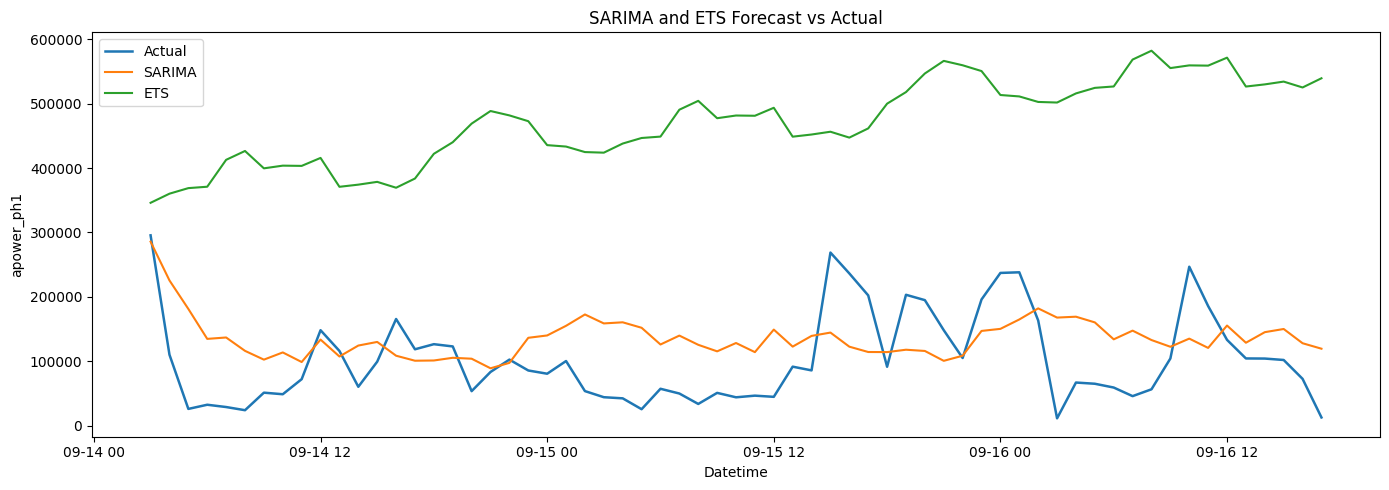

Saved: paper_sarima_ets_metrics.csv, paper_sarima_ets_predictions.csv


In [4]:
train_val = pd.concat([train, val])

sarima_model = SARIMAX(
    train_val,
    order=best_cfg[0],
    seasonal_order=best_cfg[1],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
pred_sarima = sarima_model.forecast(steps=len(test))

try:
    ets_model = ExponentialSmoothing(
        train_val,
        trend="add",
        seasonal="add",
        seasonal_periods=24,
        initialization_method="estimated"
    ).fit(optimized=True, use_brute=True)
except Exception:
    ets_model = ExponentialSmoothing(
        train_val,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit(optimized=True, use_brute=True)

pred_ets = ets_model.forecast(steps=len(test))

metrics_df = pd.DataFrame([
    metric_row("SARIMA", test.values, pred_sarima.values),
    metric_row("ETS", test.values, pred_ets.values)
])
display(metrics_df.round(4))

pred_frame = pd.DataFrame({
    "datetime": test.index,
    "actual": test.values,
    "pred_sarima": pred_sarima.values,
    "pred_ets": pred_ets.values
})

plot_n = min(300, len(pred_frame))
plt.figure(figsize=(14, 5))
plt.plot(pred_frame["datetime"].iloc[:plot_n], pred_frame["actual"].iloc[:plot_n], label="Actual", linewidth=1.8)
plt.plot(pred_frame["datetime"].iloc[:plot_n], pred_frame["pred_sarima"].iloc[:plot_n], label="SARIMA", linewidth=1.5)
plt.plot(pred_frame["datetime"].iloc[:plot_n], pred_frame["pred_ets"].iloc[:plot_n], label="ETS", linewidth=1.5)
plt.title("SARIMA and ETS Forecast vs Actual")
plt.xlabel("Datetime")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

metrics_df["BestSARIMA_Order"] = str(best_cfg[0])
metrics_df["BestSARIMA_Seasonal"] = str(best_cfg[1])
metrics_df.to_csv("paper_sarima_ets_metrics.csv", index=False)
pred_frame.to_csv("paper_sarima_ets_predictions.csv", index=False)
print("Saved: paper_sarima_ets_metrics.csv, paper_sarima_ets_predictions.csv")